In [1]:
from IPython.core.completer import GREEDY_DELIMS
from pandapower_env.data.example_configs import config_case30
import pandapower as pp
import copy
from gymnasium import spaces
from pandapower_env.environments.simulation_env import PPTopoGym
from pandapower_env.agents.benchmark_agents import DoNothingAgent, GreedyAgent
from pandapower_env.toolbox.utils_scaling import load_profile_timestep_into_net, find_scaling_recursive
from pandapower_env.toolbox.utils_profiles import (
    create_simbench_data_from_profiles,
    scale_profiles,
    get_orig_profiles,
)
from pandapower_env.action_space.action_space import create_unitary_line_actions_and_donothing
from pandapower_env.environments.simulation_env import PPTopoGym
from pandapower_env.data.utils_data import find_smooth_scenario
from pandapower_env.data.example_configs import config_case30
import copy
from gymnasium import spaces
from pandapower_env.environments.simulation_env import PPTopoGym
from pandapower_env.agents.benchmark_agents import DoNothingAgent, GreedyAgent
import copy
from gymnasium import spaces
from pandapower_env.environments.simulation_env import PPTopoGym
from pandapower_env.agents.benchmark_agents import GreedyAgent
from pandapower_env.toolbox.utils_profiles import make_constant_profiles

In [2]:
config = config_case30()
net = config["net"]
pp.runpp(net)

In [3]:
print(max(net.res_line["loading_percent"]))

14.019591289497201


In [4]:
print(net.load)

       name  bus  p_mw  q_mvar  const_z_percent  const_i_percent  sn_mva  \
0    Load 0   35   1.0     1.0              0.0              0.0     NaN   
1    Load 1    2   1.0     1.0              0.0              0.0     NaN   
2    Load 2   42   1.0     1.0              0.0              0.0     NaN   
3    Load 3    6   1.0     1.0              0.0              0.0     NaN   
4    Load 4    7   1.0     1.0              0.0              0.0     NaN   
5    Load 5   58   1.0     1.0              0.0              0.0     NaN   
6    Load 6   65   1.0     1.0              0.0              0.0     NaN   
7    Load 7   13   1.0     1.0              0.0              0.0     NaN   
8    Load 8   71   1.0     1.0              0.0              0.0     NaN   
9    Load 9   15   1.0     1.0              0.0              0.0     NaN   
10  Load 10   16   1.0     1.0              0.0              0.0     NaN   
11  Load 11   17   1.0     1.0              0.0              0.0     NaN   
12  Load 12 

In [5]:

orig_profiles = get_orig_profiles(net)
find_scaling_recursive(net, init_scaling=5, orig_profiles=orig_profiles, max_percent=150, overloaded_lines=2)

True

In [6]:
pp.runpp(net)
print(max(net.res_line["loading_percent"]))

159.1774706326545


In [7]:
scale_profiles(net,orig_profiles)
create_simbench_data_from_profiles(net, orig_profiles)

actions = create_unitary_line_actions_and_donothing(net)
config = {
    "net": net,
    "n_episodes": 1,
    "episode_length": 96,
    "action_space": actions,
    "nminus1": False,
    }
env = PPTopoGym(config)

In [8]:
env.reset(options = {"index":0})
print(max(env.net.res_line["loading_percent"]))

159.1774706326545


# Finding a smooth scenario

In [9]:

my_config = config_case30()

In [10]:
# index = find_smooth_scenario(my_config)
index = [67*96]  # manually found smooth scenario

In [11]:
print(index)
index_start = index[0]

[6432]


Max line loading %:  172.35


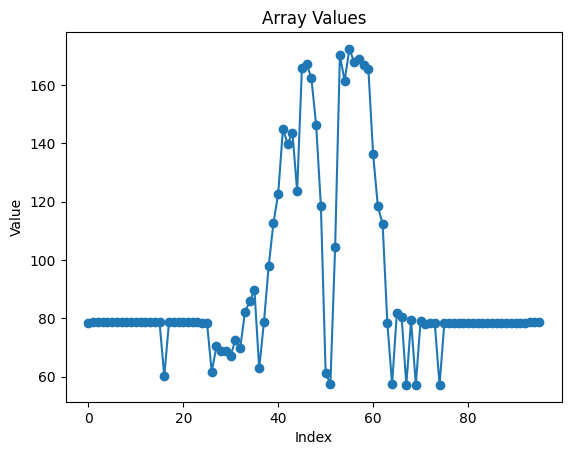

In [20]:
# DoNothing on smooth scenario


config_data = config_case30()
actions = spaces.Discrete(len(config_data["action_space"]))
config_env = copy.deepcopy(config_data)
env = PPTopoGym(config_env)
agent_dn = DoNothingAgent(actions)
ind = 96*67
obs, info = env.reset(options={"index":ind})
overloads = []
for _ in range(96):
    action = agent_dn.act(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    overloads.append(round(float(env.net.res_line.loading_percent.max()), 2))
print("Max line loading %: ", max(overloads))
# plot
import matplotlib.pyplot as plt
plt.plot(overloads, marker='o')  # marker optional
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Array Values")
plt.show()

In [13]:
# DoNothing on smooth scenario

config_data = config_case30()



In [14]:
agent_config = copy.deepcopy(config_data)
actions = spaces.Discrete(len(config_data["action_space"]))
config_env = copy.deepcopy(config_data)
env = PPTopoGym(config_env)
agent_greedy = GreedyAgent(actions, agent_config, n_workers = 16)
ind = 96*67+55
obs, info = env.reset(options={"index":ind})
overloads_greedy = []
for _ in range(2):
    action = agent_greedy.act(obs, info)
    obs, reward, terminated, truncated, info = env.step(action)
    overloads_greedy.append(round(float(env.net.res_line.loading_percent.max()), 2))
print("Max line loading %: ", max(overloads_greedy))
# plot

greedy index gotten from env:  25152
====== START state_from_info ======
index in profiles: 6488
index at end:  6488
current_step at end:  1
====== END state_from_info ======
greedy index gotten from env:  6488
Max line loading %:  173.09


In [15]:
ind = 96*67+55
obs, info = env.reset(options={"index":ind})
overloads_greedy = []
for _ in range(3):
    action = agent_greedy.act(obs, info)
    obs, reward, terminated, truncated, info = env.step(action)
    overloads_greedy.append(round(float(env.net.res_line.loading_percent.max()), 2))
    print(action)
print("Max line loading %: ", max(overloads_greedy))


greedy index gotten from env:  6488
63
====== START state_from_info ======
index in profiles: 6488
index at end:  6488
current_step at end:  1
====== END state_from_info ======
greedy index gotten from env:  6488
130
====== START state_from_info ======
index in profiles: 6489
index at end:  6489
current_step at end:  2
====== END state_from_info ======
greedy index gotten from env:  6489
210
Max line loading %:  115.22


In [16]:
print(overloads_greedy)

[115.22, 109.72, 109.28]


In [17]:
# with constant profiles


opti_timesteps = 10
config = config_case30()
make_constant_profiles(config["net"], 67*96+55, opti_timesteps)
config["episode_length"] = opti_timesteps
actions = spaces.Discrete(len(config["action_space"]))
env = PPTopoGym(config)
config_greedy = copy.deepcopy(config)
config_dn = copy.deepcopy(config)
agent_dn = DoNothingAgent(config_dn)
agent_greedy = GreedyAgent(actions, config_greedy, n_workers = 16)

In [18]:
ind = 0
obs, info = env.reset(options={"index":ind})
overloads_greedy = []
agent_greedy = GreedyAgent(actions, config_greedy, n_workers = 16)
print("Profile index range:", env.df_profiles_load_p.index)
print("Total timesteps available:", len(env.df_profiles_load_p))
done = False
count = 0 
while not done:
    print("----------------")
    print("Step: ", count)
    count += 1
    action = agent_greedy.act(obs, info)
    print("index in profiles:", agent_greedy.env.index)
    obs, reward, terminated, truncated, info = env.step(action)
    overloads_greedy.append(round(float(env.net.res_line.loading_percent.max()), 2))
    print(action)
    print(agent_greedy.env.current_step)
    
    done = terminated or truncated
    print("overload: ", overloads_greedy[-1])
print("Max line loading %: ", max(overloads_greedy))

Profile index range: RangeIndex(start=0, stop=10, step=1)
Total timesteps available: 10
----------------
Step:  0
greedy index gotten from env:  0
index in profiles: 0
63
0
overload:  107.3
----------------
Step:  1
====== START state_from_info ======
index in profiles: 1
index at end:  1
current_step at end:  1
====== END state_from_info ======
greedy index gotten from env:  1
index in profiles: 1
122
1
overload:  104.6
----------------
Step:  2
====== START state_from_info ======
index in profiles: 2
index at end:  2
current_step at end:  2
====== END state_from_info ======
greedy index gotten from env:  2
index in profiles: 2
178
2
overload:  104.25
----------------
Step:  3
====== START state_from_info ======
index in profiles: 3
index at end:  3
current_step at end:  3
====== END state_from_info ======
greedy index gotten from env:  3
index in profiles: 3
246
3
overload:  104.22
----------------
Step:  4
====== START state_from_info ======
index in profiles: 4
index at end:  4
cur

In [19]:
ind = 0
obs, info = env.reset(options={"index":ind})
overloads_dn = []
done = False
while not done:
    action = agent_dn.act(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    overloads_dn.append(round(float(env.net.res_line.loading_percent.max()), 2))
    print(action)
    print("line loading: ", overloads_dn[-1])
    done = terminated or truncated
print("Max line loading %: ", max(overloads_dn))

0
line loading:  161.41
0
line loading:  161.41
0
line loading:  161.41
0
line loading:  161.41
0
line loading:  161.41
0
line loading:  161.41
0
line loading:  161.41
0
line loading:  161.41
0
line loading:  161.41
0
line loading:  161.41
Max line loading %:  161.41
